<a href="https://colab.research.google.com/github/valentinamoruzzi/Quantum_protein_folding_exam/blob/main/Protein_folding_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Set the environment:** just a simple installation of all the libraries and software needed. The most important is the first one coming from:  https://doi.org/10.1371/journal.pone.0342012, it allows the encoding of the data as explained in teh report.

In [ ]:
!pip install qupepfold
!pip install pylatexenc
!pip install qiskit
!pip install qiskit-aer
!pip install qiskit-algorithms
!pip install scikit-learn
!pip install matplotlib
!pip install numpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 37.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 39.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 35.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 kB 2.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 3.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136817 sha256=9db27bc368de1bc632a6fecc876e8c1d941aa8f06ae0dd0833bb9d86895d6c4e
  Stored in directory: /root/.cache/pip/wheels/06/3e/78/fa1588c1ae991bbfd814af2bcac6cef7a178beee1939180d46
Successfully built pylatexenc
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 327.8/327.8 kB 5.9 MB/s eta 0:00:00


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import time

# QuPepFold
import qupepfold

# Qiskit
from qiskit.quantum_info import SparsePauliOp
from qiskit.circuit.library import RealAmplitudes
from qiskit_aer.primitives import Sampler

# Qiskit algorithms
from qiskit_algorithms.minimum_eigensolvers import SamplingVQE
from qiskit_algorithms.optimizers import COBYLA
from qiskit_algorithms.utils import algorithm_globals

# PCA
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

algorithm_globals.random_seed = 23
np.random.seed(23)

**STEP 1: DATA ENCODING** As explained in the report here we encode our data using QuPepFold, but then we will use the SparsePauliOp.

In [ ]:
# build the protein folding hamiltonian
from qupepfold import (generate_turn2qubit, build_mj_interactions, exact_hamiltonian, count_interaction_qubits)
import time

# sequence
SEQUENCE = "APRLRFY"
N = len(SEQUENCE)

# Tetrahedral turn-to-qubit encoding
turn2qubit_tuple = generate_turn2qubit(SEQUENCE)
template         = turn2qubit_tuple[0]
n_free           = template.count('q')
num_qubits_interaction = count_interaction_qubits(SEQUENCE)

print(f"Sequence:           {SEQUENCE}")

# Miyazawa-Jernigan interaction matrix
mj_matrix = build_mj_interactions(SEQUENCE)
print(f"\nMJ matrix shape: {mj_matrix.shape}")

# build complete hyper dict
hyper = {
    "protein":              SEQUENCE,
    "turn2qubit":           template,
    "numQubitsConfig":      n_free,
    "numQubitsInteraction": num_qubits_interaction,
    "interactionEnergy":    mj_matrix,
}

print(f"numQubitsConfig:      {hyper['numQubitsConfig']}")
print(f"numQubitsInteraction: {hyper['numQubitsInteraction']}")

Sequence:           APRLRFY

MJ matrix shape: (7, 7)
numQubitsConfig:      7
numQubitsInteraction: 2


In [ ]:
# Convert QuPepFold Hamiltonian to SparsePauliOp
from qiskit.quantum_info import SparsePauliOp
from qiskit.circuit.library import EfficientSU2
from qiskit_algorithms.minimum_eigensolvers import SamplingVQE
from qiskit_algorithms.optimizers import COBYLA
from qiskit_aer.primitives import Sampler
from qiskit.primitives import StatevectorSampler
from IPython.display import clear_output
import time

# enumerate all conformations
n_free = template.count('q')
num_int = hyper["numQubitsInteraction"]
total_qubits = n_free + num_int
all_bs_full = [format(i, f'0{total_qubits}b') for i in range(2**total_qubits)]
energies_full = exact_hamiltonian(all_bs_full, hyper)


# build SparsePauliOp
pauli_list = []
for bs, energy in zip(all_bs_full, energies_full):
    if abs(energy) < 1e-10:
        continue
    n = len(bs)
    for mask in range(2**n):
        coeff = energy / (2**n)
        pauli_str = []
        for i in range(n):
            bit = int(bs[n-1-i])
            if (mask >> i) & 1:
                coeff *= (-1)**bit
                pauli_str.append('Z')
            else:
                pauli_str.append('I')
        pauli_list.append((''.join(reversed(pauli_str)), coeff))

H_sparse = SparsePauliOp.from_list(pauli_list).simplify()
#print(f"Number of Pauli terms: {len(H_sparse)}")



**STEP 2: Performing algorithm** Now we can finally perform our VQE +CVaR algorithm. The details are in the report

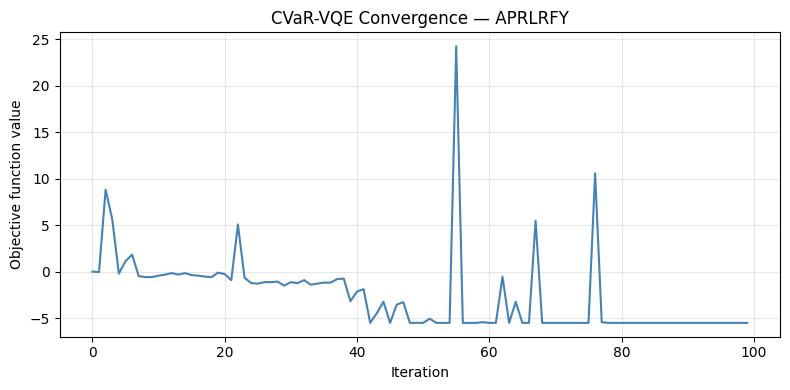


Minimum energy (baseline): -5.5193
Time elapsed:              20.20s
Iterations:                100


In [ ]:
# callback for SamplingVQE
objective_func_vals = []

def callback_graph(eval_count, params, value, metadata):
    clear_output(wait=True)
    objective_func_vals.append(value)
    plt.figure(figsize=(8, 4))
    plt.title(f"CVaR-VQE Convergence — {SEQUENCE}")
    plt.xlabel("Iteration")
    plt.ylabel("Objective function value")
    plt.plot(range(len(objective_func_vals)), objective_func_vals,
             color='steelblue', linewidth=1.5)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# run VQE with callback
ansatz    = EfficientSU2(num_qubits=H_sparse.num_qubits, reps=1)
optimizer = COBYLA(maxiter=100)
sampler   = StatevectorSampler()

vqe = SamplingVQE(
    sampler=sampler,
    ansatz=ansatz,
    optimizer=optimizer,
    aggregation=0.1,
    callback=callback_graph,
)

print("Running CVaR-VQE")
start = time.time()
result_baseline = vqe.compute_minimum_eigenvalue(H_sparse)
elapsed_baseline = time.time() - start

print(f"\nMinimum energy (baseline): {result_baseline.eigenvalue:.4f}")
print(f"Time elapsed:              {elapsed_baseline:.2f}s")
print(f"Iterations:                {len(objective_func_vals)}")

best_params_baseline = result_baseline.optimal_point

Best bitstring: 010000101
Config bits:    0100001
Turns:          [1, 0, 1, 2, 0, 1]
Energy:         -5.5193


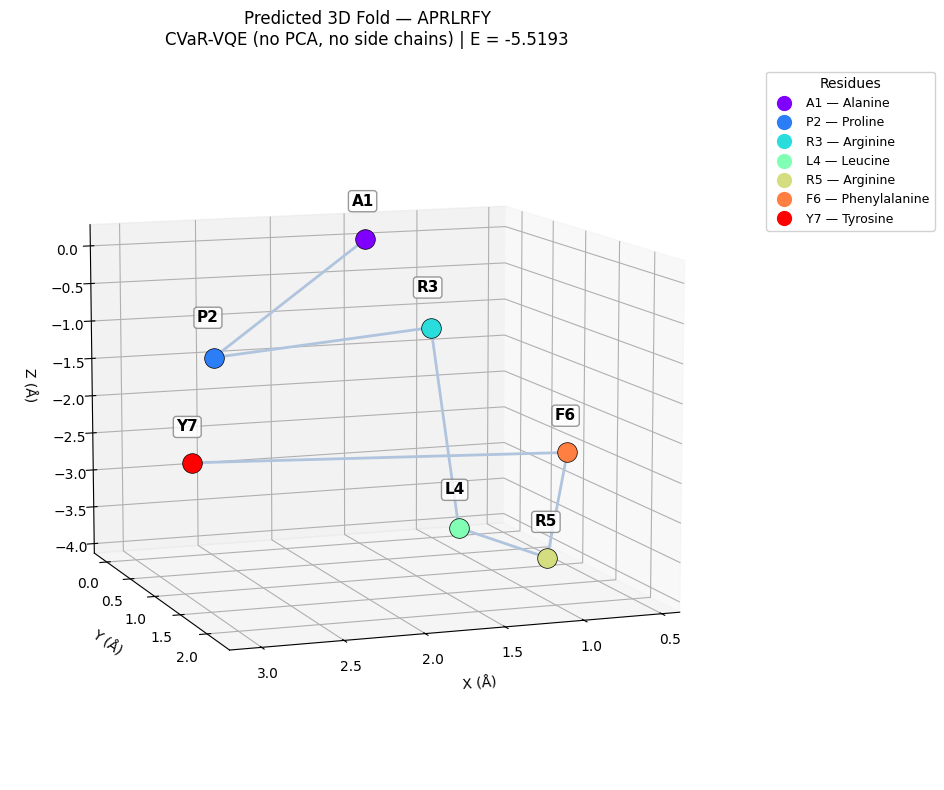

Figure saved as fold_3d.png


In [ ]:
# protein structure visualization
import qupepfold.qupepfold as qpf_module
from qiskit.quantum_info import Statevector

build_backbone_3d    = qpf_module.build_backbone_3d
dihedrals_from_turns = qpf_module.dihedrals_from_turns
turns_from_cfg_bits  = qpf_module.turns_from_cfg_bits

optimal_circuit = ansatz.assign_parameters(best_params_baseline)
optimal_circuit_no_meas = optimal_circuit.remove_final_measurements(inplace=False)

sv    = Statevector(optimal_circuit_no_meas)
probs = sv.probabilities_dict()

# Find lowest energy bitstring
states          = list(probs.keys())
energies_states = exact_hamiltonian([bs[:n_free + num_int] for bs in states], hyper)
best_bs         = states[int(np.argmin(energies_states))]
best_cfg        = best_bs[:n_free]
turns           = turns_from_cfg_bits(best_cfg, hyper["turn2qubit"])

print(f"Best bitstring: {best_bs}")
print(f"Config bits:    {best_cfg}")
print(f"Turns:          {turns}")
print(f"Energy:         {min(energies_states):.4f}")

# build 3D
phis, psis = dihedrals_from_turns(turns, len(SEQUENCE))
atoms      = build_backbone_3d(SEQUENCE, phis, psis)
ca_coords  = np.array([a["coords"] for a in atoms if a["name"] == "CA"])

# Visualize
AA_NAMES = {
    'A': 'Alanine', 'P': 'Proline', 'R': 'Arginine',
    'L': 'Leucine', 'F': 'Phenylalanine', 'Y': 'Tyrosine'
}

fig = plt.figure(figsize=(12, 8))
ax  = fig.add_subplot(111, projection='3d')

ax.plot(ca_coords[:, 0], ca_coords[:, 1], ca_coords[:, 2],
        '-', color='lightsteelblue', linewidth=2, zorder=2)

colors = plt.cm.rainbow(np.linspace(0, 1, len(SEQUENCE)))
for i, (coord, aa) in enumerate(zip(ca_coords, SEQUENCE)):
    ax.scatter(*coord, color=colors[i], s=200, zorder=5,
               edgecolors='black', linewidths=0.5)
    ax.text(coord[0] + 0.15, coord[1] + 0.15, coord[2] + 0.5,
            f'{aa}{i+1}', fontsize=11, fontweight='bold', color='black',
            bbox=dict(boxstyle='round,pad=0.2', facecolor='white',
                      edgecolor='gray', alpha=0.8))

ax.text(*ca_coords[0],  '  ', fontsize=13, color='green', fontweight='bold')
ax.text(*ca_coords[-1], '  ', fontsize=13, color='red',   fontweight='bold')

ax.set_xlabel('X (Å)', labelpad=10)
ax.set_ylabel('Y (Å)', labelpad=10)
ax.set_zlabel('Z (Å)', labelpad=10)
ax.set_title(f'Predicted 3D Fold — {SEQUENCE}\n'
             f'CVaR-VQE (no PCA, no side chains) | E = {min(energies_states):.4f}',
             fontsize=12, pad=15)
ax.view_init(elev=10, azim=70)

from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w',
           markerfacecolor=colors[i], markersize=12,
           label=f'{aa}{i+1} — {AA_NAMES.get(aa, aa)}')
    for i, aa in enumerate(SEQUENCE)
]
ax.legend(handles=legend_elements, loc='upper left',
          bbox_to_anchor=(1.05, 1), fontsize=9,
          title='Residues', title_fontsize=10, framealpha=0.9)

plt.tight_layout()
plt.savefig('fold_3d.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved as fold_3d.png")

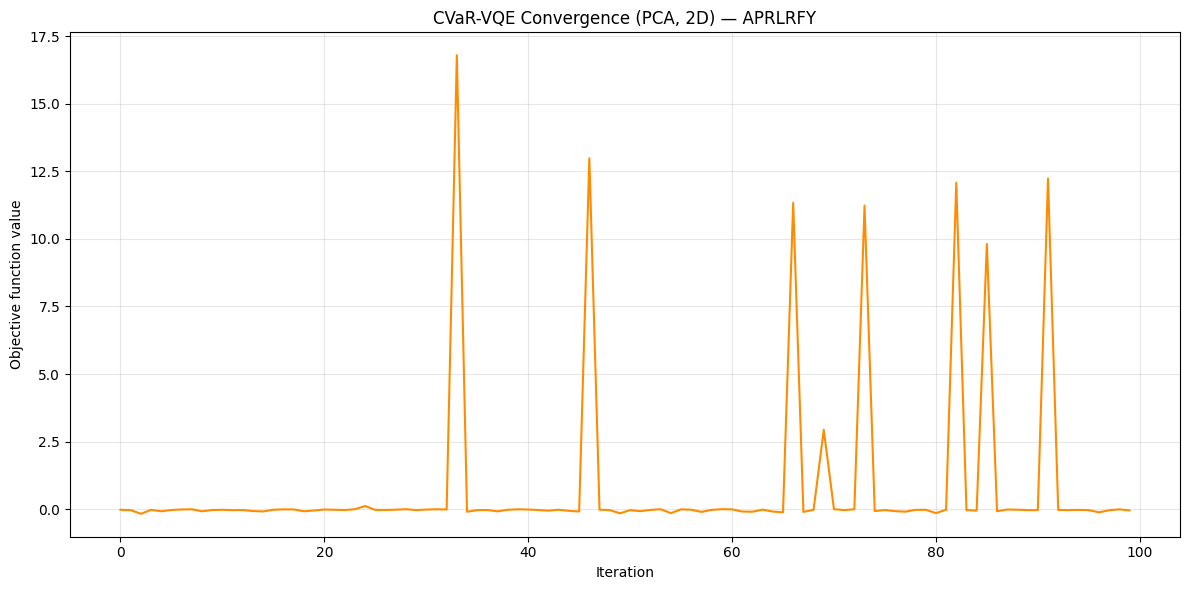

Iteration 100/100  CVaR = -0.0439

Minimum energy (PCA, 2D): -0.1698
Time elapsed (PCA):       7.50s
Optimized in 2D instead of 36D


In [ ]:
# PCA on VQE parameters thetas
from sklearn.decomposition import PCA
import seaborn as sns
import scipy.optimize as opt

n_samples = 100
D         = ansatz.num_parameters
rng       = np.random.default_rng(23)

print(f"Parameter space dimension: {D}")
print(f"Collecting {n_samples} samples...")

theta_samples  = []
cvar_labels    = []   # CVaR energy

for i in range(n_samples):
    theta = rng.uniform(-np.pi, np.pi, size=D)
    circuit = ansatz.assign_parameters(theta)
    sv      = Statevector(circuit.remove_final_measurements(inplace=False))
    probs   = sv.probabilities_dict()
    states  = list(probs.keys())
    pvals   = np.array(list(probs.values()))
    energies_s = np.array(exact_hamiltonian(
        [bs[:n_free + num_int] for bs in states], hyper
    ))
    order    = np.argsort(energies_s)
    e_sorted = energies_s[order]
    p_sorted = pvals[order]
    c        = np.cumsum(p_sorted)
    k        = int(np.searchsorted(c, 0.1, side='left'))
    weights  = np.empty(k + 1)
    weights[:k] = p_sorted[:k]
    weights[k]  = 0.1 - (float(c[k-1]) if k > 0 else 0.0)
    cvar = float(np.dot(weights, e_sorted[:k+1]) / 0.1)
    theta_samples.append(theta)
    cvar_labels.append(cvar)
    print(f"  Sample {i+1}/{n_samples}  CVaR = {cvar:.4f}")

theta_samples = np.array(theta_samples)   # shape (n_samples, D)
cvar_labels   = np.array(cvar_labels)

#  !point of no return: PCA reduce theta to 2 dimensions!

theta_samples = PCA(n_components=2).fit_transform(theta_samples)

plt.rcParams["figure.figsize"] = (6, 6)
sns.scatterplot(x=theta_samples[:, 0], y=theta_samples[:, 1],
                hue=cvar_labels, palette="RdYlGn_r", legend=False)
plt.xlabel("PC 1")
plt.ylabel("PC 2")
plt.title(f"VQE Parameters θ in PCA Space\n(color = CVaR energy)")
plt.colorbar = plt.cm.ScalarMappable(cmap='RdYlGn_r')
plt.tight_layout()
plt.savefig('pca_theta.png', dpi=150, bbox_inches='tight')
plt.show()

# fit PCA to get components for reconstruction
rng2 = np.random.default_rng(23)
theta_raw = np.array([rng2.uniform(-np.pi, np.pi, size=D) for _ in range(n_samples)])
pca_model = PCA(n_components=2)
pca_model.fit(theta_raw)

print(f"\nPCA components: {pca_model.n_components_} / {D}")
print(f"Explained variance: {pca_model.explained_variance_ratio_}")
print(f"Total explained:    {pca_model.explained_variance_ratio_.sum():.3f}")

# CVaR-VQE in 2D PCA space
print("\nRunning CVaR-VQE in PCA-reduced θ space (2D)...")

def cvar_pca_objective(z):
    """CVaR objective in 2D PCA space."""
    theta_reconstructed = pca_model.inverse_transform(z.reshape(1, -1)).flatten()
    circuit    = ansatz.assign_parameters(theta_reconstructed)
    sv         = Statevector(circuit.remove_final_measurements(inplace=False))
    probs      = sv.probabilities_dict()
    states     = list(probs.keys())
    pvals      = np.array(list(probs.values()))
    energies_s = np.array(exact_hamiltonian(
        [bs[:n_free + num_int] for bs in states], hyper
    ))
    order    = np.argsort(energies_s)
    e_sorted = energies_s[order]
    p_sorted = pvals[order]
    c        = np.cumsum(p_sorted)
    k        = int(np.searchsorted(c, 0.1, side='left'))
    weights  = np.empty(k + 1)
    weights[:k] = p_sorted[:k]
    weights[k]  = 0.1 - (float(c[k-1]) if k > 0 else 0.0)
    return float(np.dot(weights, e_sorted[:k+1]) / 0.1)

objective_func_vals_pca = []
best_pca_energy = float('inf')
best_pca_z      = None
rng3 = np.random.default_rng(42)

plt.rcParams["figure.figsize"] = (12, 6)

start_pca = time.time()
for i in range(100):
    z0  = rng3.uniform(-np.pi, np.pi, size=2)
    res = opt.minimize(cvar_pca_objective, z0, method='COBYLA',
                       options={'maxiter': 1, 'rhobeg': 0.5})
    val = cvar_pca_objective(res.x)
    objective_func_vals_pca.append(val)
    if val < best_pca_energy:
        best_pca_energy = val
        best_pca_z      = res.x
    if (i + 1) % 10 == 0:
        clear_output(wait=True)
        plt.figure(figsize=(12, 6))
        plt.title(f"CVaR-VQE Convergence (PCA, 2D) — {SEQUENCE}")
        plt.xlabel("Iteration")
        plt.ylabel("Objective function value")
        plt.plot(range(len(objective_func_vals_pca)), objective_func_vals_pca,
                 color='darkorange', linewidth=1.5)
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()
        print(f"Iteration {i+1}/100  CVaR = {val:.4f}")

elapsed_pca = time.time() - start_pca

# Reconstruct
best_params_pca = pca_model.inverse_transform(best_pca_z.reshape(1, -1)).flatten()

print(f"\nMinimum energy (PCA, 2D): {best_pca_energy:.4f}")
print(f"Time elapsed (PCA):       {elapsed_pca:.2f}s")
print(f"Optimized in 2D instead of {D}D")

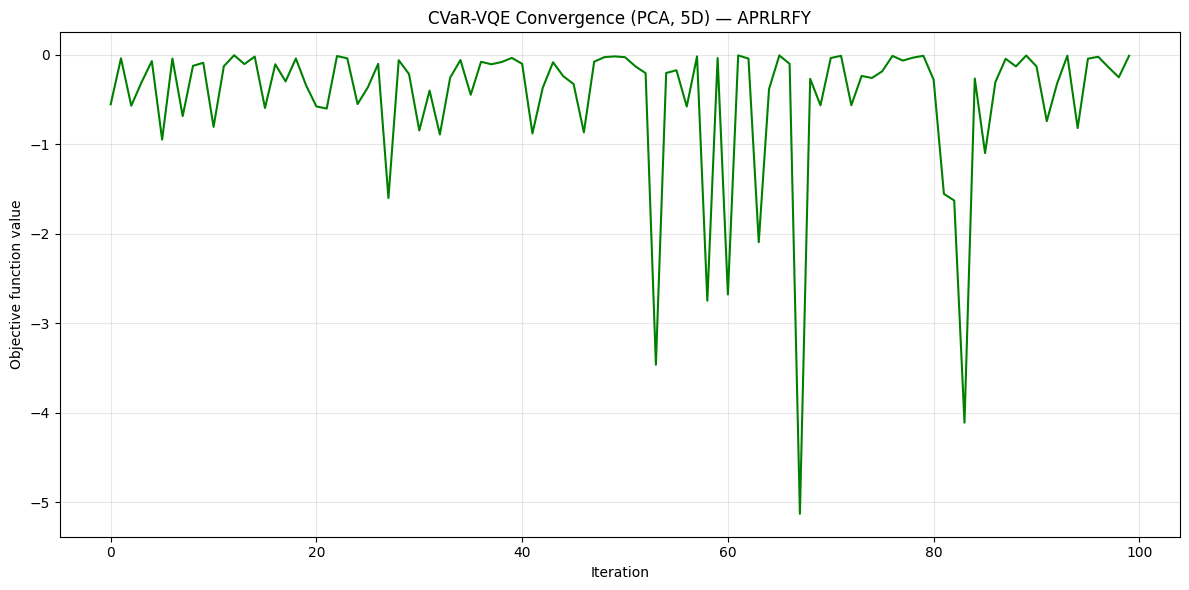

Iteration 100/100  CVaR = -0.0133

Minimum energy (PCA, 5D): -5.1307
Time elapsed (PCA 5D):    10.02s
Optimized in 5D instead of 36D


In [ ]:
# CVaR-VQE with PCA (5 components)
# theta_samples is overwritten and lost, but the 5D case is handled separately
# by regenerating the same dataset from scratch using the same seed (rng5 = default_rng(23))
objective_func_vals_pca5 = []
best_pca5_energy = float('inf')
best_pca5_z      = None
rng4 = np.random.default_rng(42)

# Refit PCA with 5 components on fresh random samples
rng5 = np.random.default_rng(23)
theta_raw5 = np.array([rng5.uniform(-np.pi, np.pi, size=D) for _ in range(n_samples)])
pca_model5 = PCA(n_components=5)
pca_model5.fit(theta_raw5)

print(f"PCA components: 5 / {D}")
print(f"Explained variance: {pca_model5.explained_variance_ratio_}")
print(f"Total explained:    {pca_model5.explained_variance_ratio_.sum():.3f}")

def cvar_pca5_objective(z):
    theta_reconstructed = pca_model5.inverse_transform(z.reshape(1, -1)).flatten()
    circuit    = ansatz.assign_parameters(theta_reconstructed)
    sv         = Statevector(circuit.remove_final_measurements(inplace=False))
    probs      = sv.probabilities_dict()
    states     = list(probs.keys())
    pvals      = np.array(list(probs.values()))
    energies_s = np.array(exact_hamiltonian(
        [bs[:n_free + num_int] for bs in states], hyper
    ))
    order    = np.argsort(energies_s)
    e_sorted = energies_s[order]
    p_sorted = pvals[order]
    c        = np.cumsum(p_sorted)
    k        = int(np.searchsorted(c, 0.1, side='left'))
    weights  = np.empty(k + 1)
    weights[:k] = p_sorted[:k]
    weights[k]  = 0.1 - (float(c[k-1]) if k > 0 else 0.0)
    return float(np.dot(weights, e_sorted[:k+1]) / 0.1)

plt.rcParams["figure.figsize"] = (12, 6)
start_pca5 = time.time()

for i in range(100):
    z0  = rng4.uniform(-np.pi, np.pi, size=5)
    res = opt.minimize(cvar_pca5_objective, z0, method='COBYLA',
                       options={'maxiter': 1, 'rhobeg': 0.5})
    val = cvar_pca5_objective(res.x)
    objective_func_vals_pca5.append(val)
    if val < best_pca5_energy:
        best_pca5_energy = val
        best_pca5_z      = res.x
    if (i + 1) % 10 == 0:
        clear_output(wait=True)
        plt.figure(figsize=(12, 6))
        plt.title(f"CVaR-VQE Convergence (PCA, 5D) — {SEQUENCE}")
        plt.xlabel("Iteration")
        plt.ylabel("Objective function value")
        plt.plot(range(len(objective_func_vals_pca5)), objective_func_vals_pca5,
                 color='green', linewidth=1.5)
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()
        print(f"Iteration {i+1}/100  CVaR = {val:.4f}")

elapsed_pca5 = time.time() - start_pca5
best_params_pca5 = pca_model5.inverse_transform(best_pca5_z.reshape(1, -1)).flatten()

print(f"\nMinimum energy (PCA, 5D): {best_pca5_energy:.4f}")
print(f"Time elapsed (PCA 5D):    {elapsed_pca5:.2f}s")
print(f"Optimized in 5D instead of {D}D")

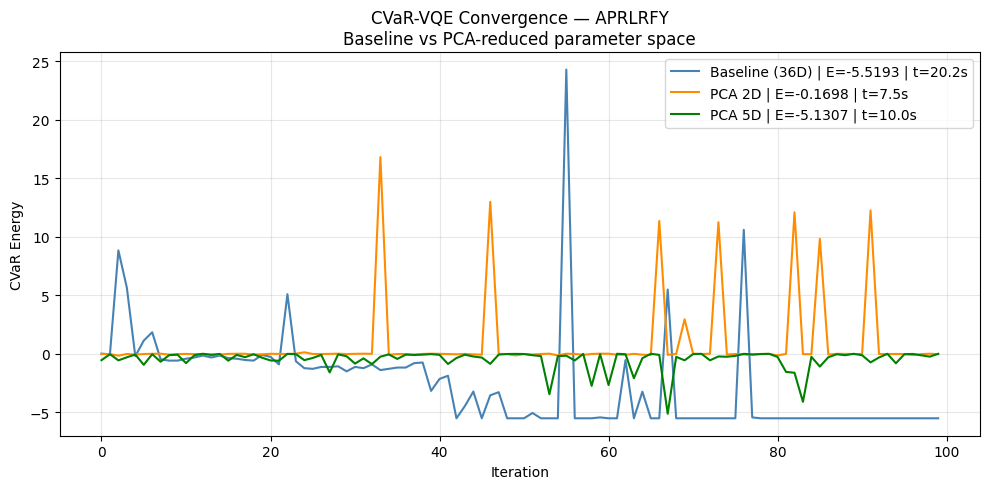


── Summary ──────────────────────────────────────────────────────
Method                 Dimensions   Min Energy   Time (s)    Speedup
--------------------------------------------------------------------
Baseline                       36      -5.5193      20.20      1.00x
PCA 2D                          2      -0.1698       7.50      2.69x
PCA 5D                          5      -5.1307      10.02      2.01x

Energy error (PCA 2D vs baseline)        5.3495
Energy error (PCA 5D vs baseline)        0.3886


In [ ]:
# Final comparison

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(objective_func_vals,      color='steelblue',  linewidth=1.5,
        label=f'Baseline ({D}D) | E={result_baseline.eigenvalue:.4f} | t={elapsed_baseline:.1f}s')
ax.plot(objective_func_vals_pca,  color='darkorange', linewidth=1.5,
        label=f'PCA 2D | E={best_pca_energy:.4f} | t={elapsed_pca:.1f}s')
ax.plot(objective_func_vals_pca5, color='green',      linewidth=1.5,
        label=f'PCA 5D | E={best_pca5_energy:.4f} | t={elapsed_pca5:.1f}s')
ax.set_xlabel('Iteration')
ax.set_ylabel('CVaR Energy')
ax.set_title(f'CVaR-VQE Convergence — {SEQUENCE}\nBaseline vs PCA-reduced parameter space')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('final_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary table
print('\n── Summary ──────────────────────────────────────────────────────')
print(f"{'Method':<20} {'Dimensions':>12} {'Min Energy':>12} {'Time (s)':>10} {'Speedup':>10}")
print('-' * 68)

methods_   = ['Baseline', 'PCA 2D', 'PCA 5D']
energies_  = [result_baseline.eigenvalue, best_pca_energy, best_pca5_energy]
times_     = [elapsed_baseline, elapsed_pca, elapsed_pca5]
dims_      = [D, 2, 5]

for method, dim, energy, t in zip(methods_, dims_, energies_, times_):
    speedup = elapsed_baseline / t if t > 0 else float('inf')
    print(f"{method:<20} {dim:>12} {energy:>12.4f} {t:>10.2f} {speedup:>9.2f}x")

print()
print(f"{'Energy error (PCA 2D vs baseline)':<40} {abs(best_pca_energy - result_baseline.eigenvalue):.4f}")
print(f"{'Energy error (PCA 5D vs baseline)':<40} {abs(best_pca5_energy - result_baseline.eigenvalue):.4f}")